In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter

In [ ]:
n = 6
thetas = [Parameter(f"θ{i+1}") for i in range(n)]

qr = QuantumRegister(n, 'q')
cr = ClassicalRegister(n, 'c')
qc = QuantumCircuit(qr, cr)

# 1) H en todos
for i in range(n):
    qc.h(qr[i])

# 2) Ry en todos
for i in range(n):
    qc.ry(thetas[i], qr[i])

# 3) Rx en todos
for i in range(n):
    qc.rx(thetas[i], qr[i])

# 4) CNOTs en pares (0-1, 2-3, 4-5)
for i in range(0, n, 2):
    qc.cx(qr[i], qr[i+1])

# 5) Ry en todos
for i in range(n):
    qc.ry(thetas[i], qr[i])

# 6) Mediciones
for i in range(n):
    qc.measure(qr[i], cr[i])

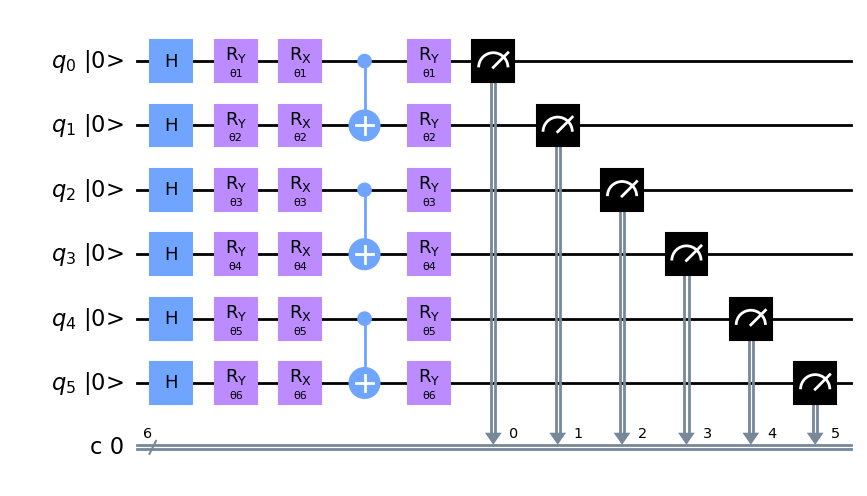

In [ ]:
# Dibuja el circuito con el estado inicial
qc.draw('mpl', initial_state=True)

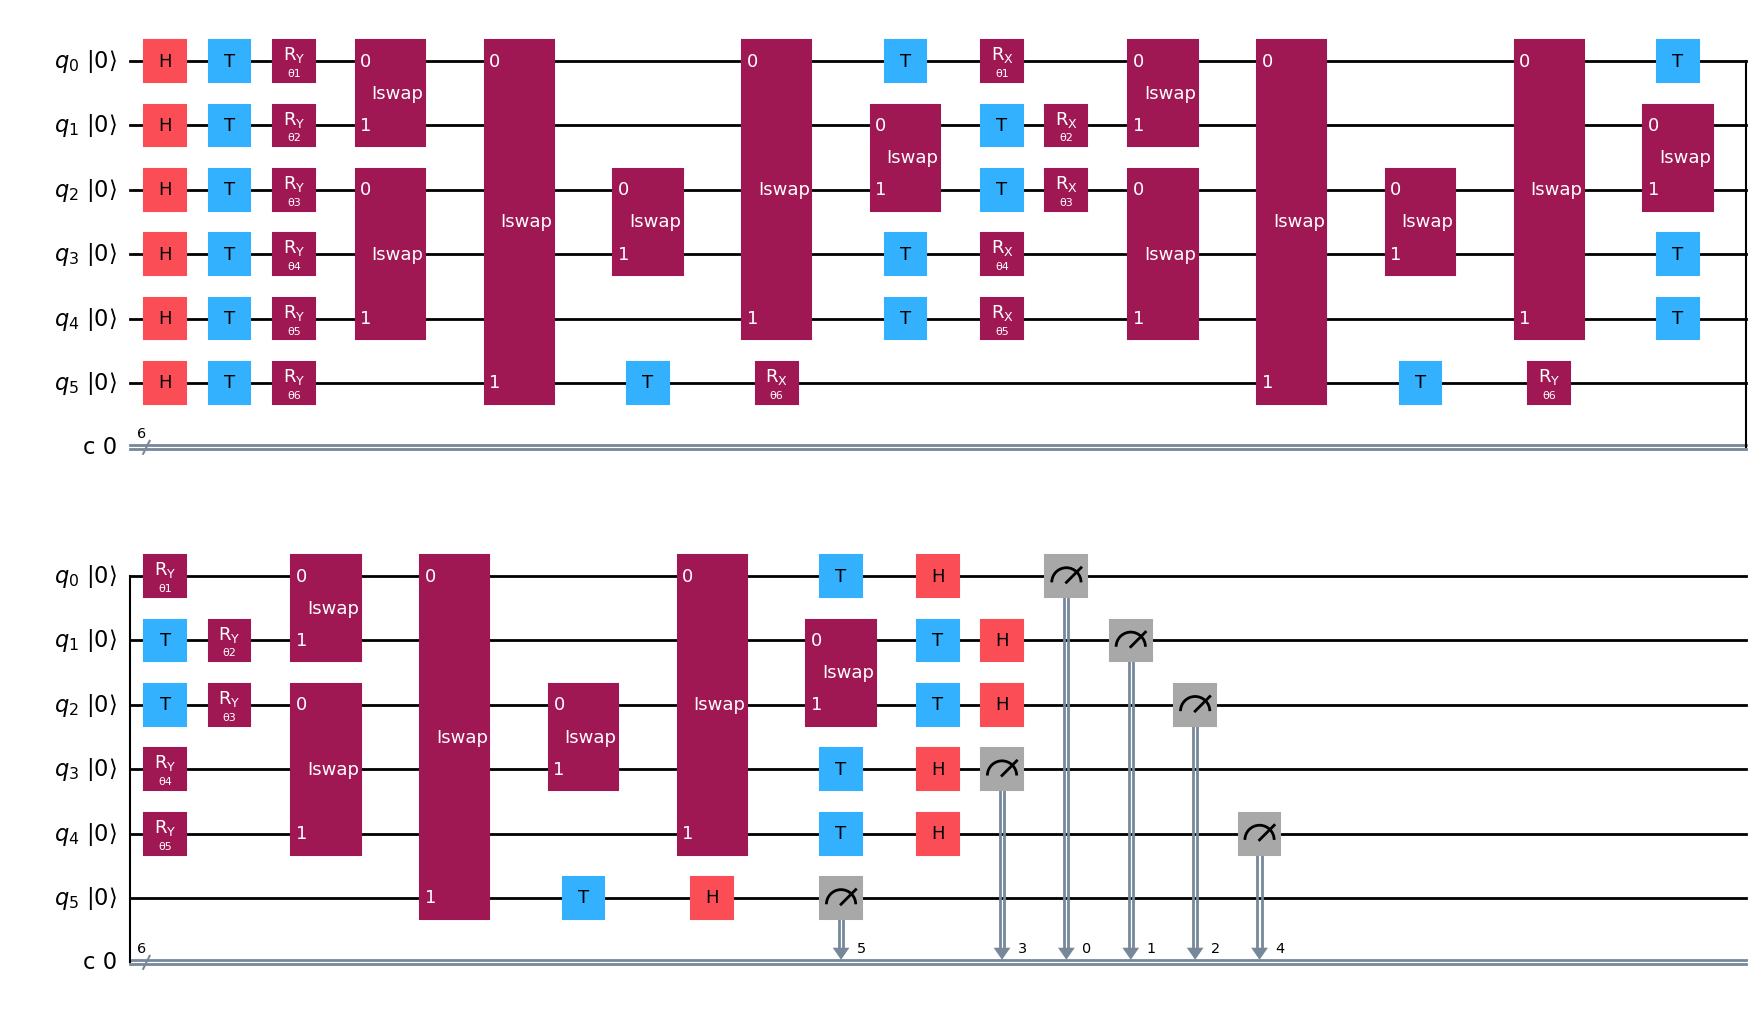

In [1]:
# Circuito real del pipeline QHRP (version simulacion/base del proyecto)
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter

n_real = 6
thetas_real = [Parameter(f"θ{i+1}") for i in range(n_real)]
entanglement_pairs = [(0, 1), (0, 5), (2, 4), (0, 4), (2, 3), (1, 2)]

qr_real = QuantumRegister(n_real, "q")
cr_real = ClassicalRegister(n_real, "c")
qc_real = QuantumCircuit(qr_real, cr_real)

# Estado inicial en superposicion
for i in range(n_real):
    qc_real.h(qr_real[i])

# Ronda 1: T + RY(theta) y entrelazamiento iSWAP
for i in range(n_real):
    qc_real.t(qr_real[i])
    qc_real.ry(thetas_real[i], qr_real[i])
for i, j in entanglement_pairs:
    qc_real.iswap(qr_real[i], qr_real[j])

# Ronda 2: T + RX(theta) y entrelazamiento iSWAP
for i in range(n_real):
    qc_real.t(qr_real[i])
    qc_real.rx(thetas_real[i], qr_real[i])
for i, j in entanglement_pairs:
    qc_real.iswap(qr_real[i], qr_real[j])

# Ronda 3: T + RY(theta) y entrelazamiento iSWAP
for i in range(n_real):
    qc_real.t(qr_real[i])
    qc_real.ry(thetas_real[i], qr_real[i])
for i, j in entanglement_pairs:
    qc_real.iswap(qr_real[i], qr_real[j])

# Capa final y medicion
for i in range(n_real):
    qc_real.t(qr_real[i])
    qc_real.h(qr_real[i])
    qc_real.measure(qr_real[i], cr_real[i])

qc_real.draw("mpl", initial_state=True)